In [ ]:
# Load, explore and plot data
import numpy as np #multidimensional array banate use kore
import pandas as pd #reads data from csv file, analyses data
import matplotlib.pyplot as plt #helps woth data visualisation, used to show any characteristics of data
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
%matplotlib inline
from sklearn.metrics import f1_score, precision_score, recall_score
# Train test split
from sklearn.model_selection import train_test_split #manually dataset ke train test e split kora lagena, scikit learn does it for us in one command
from sklearn.metrics import classification_report
# Text pre-processing
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer #sentence ke word e break down kore, lowercase kore, removes punctuation
from tensorflow.keras.preprocessing.sequence import pad_sequences #ekek sentence ekek length hoy, so maximum length of sentence ke max_length dhore choto size sentence gulake padding kore
from tensorflow.keras.callbacks import EarlyStopping #not necessary for project, it stops model if it overfits

# Modeling
from tensorflow.keras.models import Sequential #NN is object of sequential class, amader data sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Embedding, Dropout, GlobalAveragePooling1D, Flatten, SpatialDropout1D, Bidirectional
import os
from keras import backend as K


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
#Dataset has to be download in personal pc. Erpor ei function ta pc er joto drive ache, shob drive er shob folders e traverse kore khujbe, jekhanei pabe oikhan theke location return kore dibe. oi location amra porer function e use korbo.
#File er naam for sure train.csv hote hobe, ei function ta train.csv dhore khujtese
def search_for_dataset(dataset_name):
    dataset_path = None
    drives = [f"{chr(x)}:/" for x in range(65, 91) if os.path.exists(f"{chr(x)}:/")]
    for drive in drives:
        print(f"Searching in {drive}...")
        for dirpath, dirnames, filenames in os.walk(drive):
            for filename in filenames:
                if filename == dataset_name:
                    dataset_path = os.path.join(dirpath, filename)
                    return dataset_path
    return dataset_path
#same thing, just train.csv er bodole glove file khujtese jeta text file
def search_for_text_file(file_name):
    drives = [f"{chr(x)}:/" for x in range(65, 91) if os.path.exists(f"{chr(x)}:/")]
    for drive in drives:
        print(f"Searching in {drive}...")
        for dirpath, dirnames, filenames in os.walk(drive):
            for filename in filenames:
                if filename == file_name and filename.endswith(".txt"):
                    return os.path.join(dirpath, filename)
    return None


dataset_name = 'train.csv'  # Your exact dataset name
dataset_path = search_for_dataset(dataset_name)

if dataset_path:
    print(f"Dataset found at: {dataset_path}")
else:
    print("Dataset not found.")

Searching in C:/...
Searching in D:/...
Dataset found at: D:/SteamLibrary\steamapps\common\The Crew 2\train.csv


In [ ]:
df = pd.read_csv(dataset_path, encoding='ISO-8859-1') #amar drive mount kore, oitay public kora traincsv file ta access korchi
# rename the columns
df = df[['text','target']] #as mentioned, i am only working with text and target columns of the dataset amongst all the columns
df.rename(columns={'text':'text', 'target':'target'}, inplace=True) #oigula rename kore same name ee rakhchi
df.head()

,text,target
0,Our Deeds are the Reason of this #earthquake M...,1
1,Forest fire near La Ronge Sask. Canada,1
2,All residents asked to 'shelter in place' are ...,1
3,"13,000 people receive #wildfires evacuation or...",1
4,Just got sent this photo from Ruby #Alaska as ...,1


In [ ]:
df.describe()

,target
count,7613.00000
mean,0.42966
std,0.49506
min,0.00000
25%,0.00000
50%,0.00000
75%,1.00000
max,1.00000


In [ ]:
print(df.columns) #checking ki ki column ache

Index(['text', 'target'], dtype='object')


In [ ]:
df.groupby('target').describe().T #target naam er column diye grouping korchi

target                                                       0  \
text count                                                4342   
     unique                                               4315   
     top     The Prophet (peace be upon him) said 'Save you...   
     freq                                                    4   

target                                                       1  
text count                                                3271  
     unique                                               3206  
     top     11-Year-Old Boy Charged With Manslaughter of T...  
     freq                                                   10

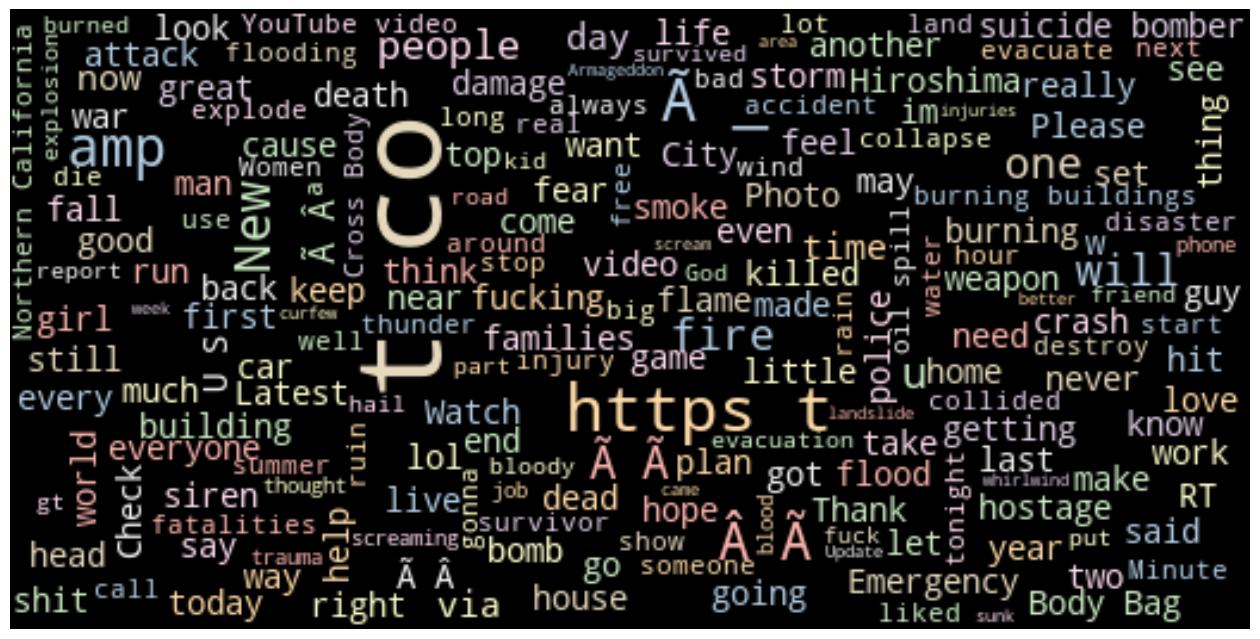

In [ ]:
ham_msg_text = ' '.join(df['text'].dropna().astype(str).tolist()) #text column er data gulake wordcloud e represent korlam
ham_msg_cloud = WordCloud(width =520, height =260, stopwords = STOPWORDS, max_font_size = 50, background_color = "black", colormap = 'Pastel1').generate(ham_msg_text)
plt.figure(figsize=(16,10))
plt.imshow(ham_msg_cloud, interpolation = 'bilinear')
plt.axis('off') # turn off axis
plt.show()

In [ ]:
#Get length column for each text and convert the text label to numeric value:
df['text_length'] = df['text'].apply(len)
df['msg_type'] = df['target'].map({0:0, 1:1})
msg_label =df['msg_type'].values
df.head()

,text,target,text_length,msg_type
0,Our Deeds are the Reason of this #earthquake M...,1,69,1
1,Forest fire near La Ronge Sask. Canada,1,38,1
2,All residents asked to 'shelter in place' are ...,1,133,1
3,"13,000 people receive #wildfires evacuation or...",1,65,1
4,Just got sent this photo from Ruby #Alaska as ...,1,88,1


**Train - Test split** (80 - 20 ratio)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(df['text'], msg_label, test_size=0.2, random_state=434)

**Tokenization-sentence ke word e break down kore, lowercase kore, removes punctuation**

In [ ]:
#aage text column er kon sentence er length maximum oita ke max_len variable e store korchi
max_len = df['text'].apply(len).max()
# Output the max length
print(max_len)


163


In [ ]:
# Defining pre-processing parameters
max_len = max_len
trunc_type = 'post'
padding_type = 'post'
oov_tok = '<OOV>' # out of vocabulary token
vocab_size = 500

In [ ]:
tokenizer = Tokenizer(num_words = vocab_size, #num_words : how many unique word that we want to load in training and testing data
                      char_level = False,
                      oov_token = oov_tok) #out of vocabulary token: This is used to replace out of vocabulary words (words that are not in our corpus) during text_to_sequence calls.
tokenizer.fit_on_texts(x_train)

In [ ]:
# Get the word_index
word_index = tokenizer.word_index
total_words = len(word_index)
total_words

19415

**Sequence and** **padding** (ekek sentence ekek length hoy, so maximum length of sentence ke max_length dhore choto size sentence gulake padding kore)

In [ ]:
training_sequences = tokenizer.texts_to_sequences(x_train) #train data ke tokenise kore padding korchi
training_padded = pad_sequences(training_sequences,
                                maxlen = max_len,
                                padding = padding_type,
                                truncating = trunc_type)

In [ ]:
testing_sequences = tokenizer.texts_to_sequences(x_test) #test data keo tokenise kore padding korchi
testing_padded = pad_sequences(testing_sequences,
                               maxlen = max_len,
                               padding = padding_type,
                               truncating = trunc_type)

In [ ]:
print('Shape of training tensor: ', training_padded.shape)
print('Shape of testing tensor: ', testing_padded.shape)

Shape of training tensor:  (6090, 163)
Shape of testing tensor:  (1523, 163)


**Calculating F1 Score**


In [ ]:
def calculateF1Score(testing_padded,y_test, model):
    y_pred_probs = model.predict(testing_padded)
    y_pred = (y_pred_probs > 0.4).astype(int)
    f1 = f1_score(y_test, y_pred)
    return f1

**Using LSTM first**

In [ ]:
# Define parameter , egula hyperparameters
vocab_size = 19416
embedding_dim = 50
drop_value = 0.2
n_dense = 24

**Creating the embedding matrix**

In [ ]:
def create_embedding_matrix(filepath, word_index, embedding_dim): #notun embedding layer, more complex
    vocab_size = len(word_index) + 1  # Adding again 1 because of reserved 0 index
    embedding_matrix = np.zeros((vocab_size, embedding_dim))

    with open(filepath, encoding="utf8") as f:
        for line in f:
            word, *vector = line.split()
            if word in word_index:
                idx = word_index[word]
                embedding_matrix[idx] = np.array(
                    vector, dtype=np.float32)[:embedding_dim]
    return embedding_matrix
file_path = search_for_text_file("glove.6B.50d.txt")
if file_path:
    print(f"File found at: {file_path}")
else:
    print("File not found")
embedding_matrix = create_embedding_matrix(file_path, tokenizer.word_index, embedding_dim)

Searching in C:/...
Searching in D:/...
File found at: D:/glove.6B.50d.txt


**Compile the model**

In [ ]:
# Define parameter
n_lstm = 128
drop_lstm = 0.2
# Define LSTM Model
model1 = Sequential()
model1.add(Embedding(vocab_size, embedding_dim,
                           weights=[embedding_matrix],
                           input_length=max_len,
                           trainable=False))
model1.add(SpatialDropout1D(drop_lstm))
model1.add(LSTM(n_lstm, return_sequences=False))
model1.add(Dropout(drop_lstm))
model1.add(Dense(1, activation='sigmoid'))
model1.build(input_shape =( None, max_len))

In [ ]:
model1.compile(loss = 'binary_crossentropy', optimizer = 'adam' , metrics = ['accuracy'])

In [ ]:
model1.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_8 (Embedding)     (None, 163, 50)           970800    
                                                                 
 spatial_dropout1d_4 (Spatia  (None, 163, 50)          0         
 lDropout1D)                                                     
                                                                 
 lstm_4 (LSTM)               (None, 128)               91648     
                                                                 
 dropout_6 (Dropout)         (None, 128)               0         
                                                                 
 dense_6 (Dense)             (None, 1)                 129       
                                                                 
Total params: 1,062,577
Trainable params: 91,777
Non-trainable params: 970,800
_________________________________________

**Train the model**



In [ ]:
num_epochs = 30
early_stop = EarlyStopping(monitor='val_loss', patience=3)
history = model1.fit(training_padded,
                     y_train,
                     epochs=num_epochs,
                     validation_data=(testing_padded, y_test),
                     callbacks =[early_stop],
                     verbose=2)

Epoch 1/30
191/191 - 9s - loss: 0.6827 - accuracy: 0.5736 - val_loss: 0.6877 - val_accuracy: 0.5575 - 9s/epoch - 48ms/step
Epoch 2/30
191/191 - 9s - loss: 0.6828 - accuracy: 0.5736 - val_loss: 0.6867 - val_accuracy: 0.5575 - 9s/epoch - 50ms/step
Epoch 3/30
191/191 - 9s - loss: 0.6825 - accuracy: 0.5736 - val_loss: 0.6872 - val_accuracy: 0.5575 - 9s/epoch - 49ms/step
Epoch 4/30
191/191 - 9s - loss: 0.6826 - accuracy: 0.5736 - val_loss: 0.6866 - val_accuracy: 0.5575 - 9s/epoch - 49ms/step
Epoch 5/30
191/191 - 9s - loss: 0.6824 - accuracy: 0.5736 - val_loss: 0.6866 - val_accuracy: 0.5575 - 9s/epoch - 49ms/step
Epoch 6/30
191/191 - 9s - loss: 0.6826 - accuracy: 0.5736 - val_loss: 0.6868 - val_accuracy: 0.5575 - 9s/epoch - 48ms/step
Epoch 7/30
191/191 - 9s - loss: 0.6826 - accuracy: 0.5736 - val_loss: 0.6872 - val_accuracy: 0.5575 - 9s/epoch - 49ms/step


**Plotting graph of accuracy of train and validation**

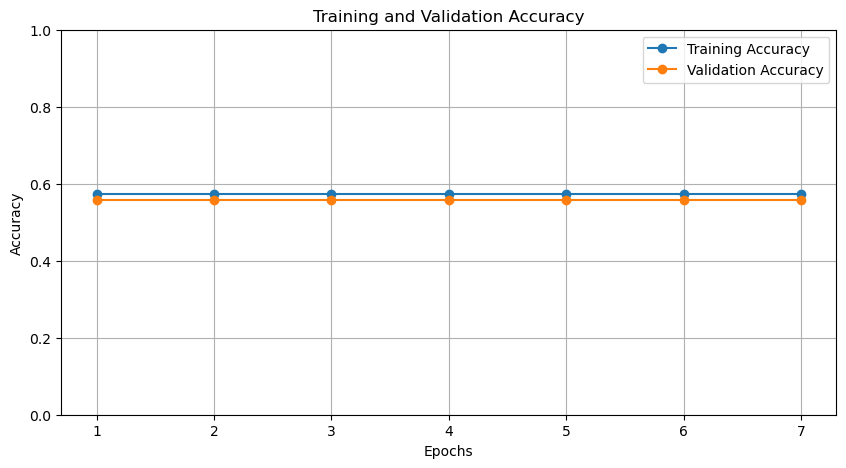

In [ ]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(train_accuracy) + 1)
# Plotting er code
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accuracy, label='Training Accuracy', marker='o')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(epochs)
plt.ylim([0, 1])
plt.legend()
plt.grid()
plt.show()


**Plotting graph of loss of train and validation**

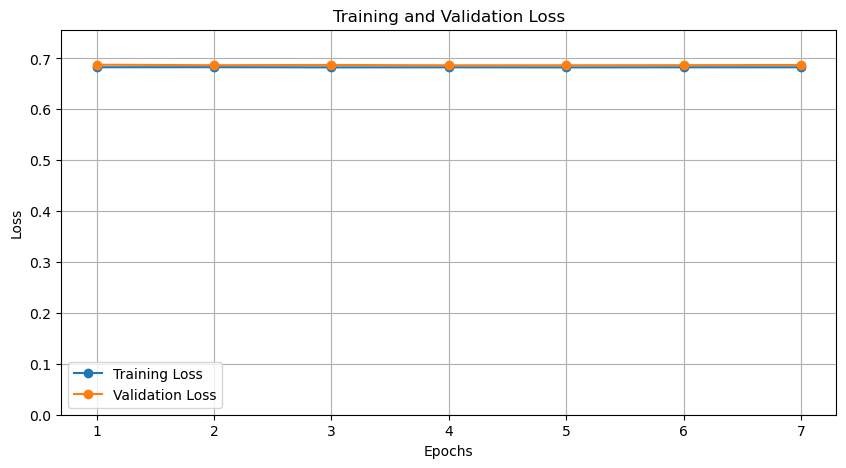

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)
# Plotting er code
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.ylim([0, max(max(train_loss), max(val_loss)) * 1.1])  # Adjust y-axis based on loss values
plt.legend()
plt.grid()
plt.show()


**Printing the accuracy and F1 score of train and valid data:**

In [ ]:
f1_1 = calculateF1Score(testing_padded, y_test, model1)
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy1 = history.history['val_accuracy'][-1]
print(f"Training Accuracy: {final_train_accuracy:.4f}")
print(f"Validation Accuracy: {final_val_accuracy1:.4f}")
print(f'F1 Score: {f1_1:.4f}')

48/48 [==============================] - 1s 20ms/step
Training Accuracy: 0.5736
Validation Accuracy: 0.5575
F1 Score: 0.6136


**Using Bi-LSTM**

In [ ]:
# Define parameter , egula hyperparameters
vocab_size = 19416
embedding_dim = 50
drop_value = 0.2
n_dense = 24

In [ ]:
#embedding_matrix = create_embedding_matrix('/content/glove.6B.50d.txt',tokenizer.word_index, embedding_dim) #calling that notun embedding layer

In [ ]:
# Define parameter
n_lstm = 128
drop_lstm = 0.2
model2 = Sequential()
model2.add(Embedding(vocab_size, embedding_dim,
                           weights=[embedding_matrix],
                           input_length=max_len,
                           trainable=False))
model2.add(Bidirectional(LSTM(n_lstm,
                              return_sequences = False))) #shudhu last layer er output dibe, majher gula dibena
model2.add(Dropout(drop_lstm))
model2.add(Dense(1, activation='sigmoid'))
model2.build(input_shape =( None, max_len))

**Compile the model**

In [ ]:
model2.compile(loss = 'binary_crossentropy',
               optimizer = 'adam',
               metrics=['accuracy'])

In [ ]:
model2.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_9 (Embedding)     (None, 163, 50)           970800    
                                                                 
 bidirectional_2 (Bidirectio  (None, 256)              183296    
 nal)                                                            
                                                                 
 dropout_7 (Dropout)         (None, 256)               0         
                                                                 
 dense_7 (Dense)             (None, 1)                 257       
                                                                 
Total params: 1,154,353
Trainable params: 183,553
Non-trainable params: 970,800
_________________________________________________________________


**Train model**

In [ ]:
num_epochs = 30
early_stop = EarlyStopping(monitor = 'val_loss',
                           patience = 3)
history = model2.fit(training_padded,
                     y_train,
                     epochs = num_epochs,
                     validation_data = (testing_padded, y_test),
                     callbacks = [early_stop],
                     verbose = 2)

Epoch 1/30
191/191 - 23s - loss: 0.5479 - accuracy: 0.7268 - val_loss: 0.5056 - val_accuracy: 0.7544 - 23s/epoch - 123ms/step
Epoch 2/30
191/191 - 20s - loss: 0.5004 - accuracy: 0.7609 - val_loss: 0.4935 - val_accuracy: 0.7656 - 20s/epoch - 105ms/step
Epoch 3/30
191/191 - 20s - loss: 0.4853 - accuracy: 0.7691 - val_loss: 0.4933 - val_accuracy: 0.7551 - 20s/epoch - 103ms/step
Epoch 4/30
191/191 - 20s - loss: 0.4756 - accuracy: 0.7768 - val_loss: 0.4805 - val_accuracy: 0.7676 - 20s/epoch - 103ms/step
Epoch 5/30
191/191 - 20s - loss: 0.4664 - accuracy: 0.7821 - val_loss: 0.4846 - val_accuracy: 0.7669 - 20s/epoch - 104ms/step
Epoch 6/30
191/191 - 20s - loss: 0.4570 - accuracy: 0.7929 - val_loss: 0.4933 - val_accuracy: 0.7571 - 20s/epoch - 103ms/step
Epoch 7/30
191/191 - 20s - loss: 0.4448 - accuracy: 0.7966 - val_loss: 0.4768 - val_accuracy: 0.7695 - 20s/epoch - 103ms/step
Epoch 8/30
191/191 - 19s - loss: 0.4388 - accuracy: 0.7992 - val_loss: 0.4861 - val_accuracy: 0.7768 - 19s/epoch - 102

**Plotting graph of accuracy of train and validation**

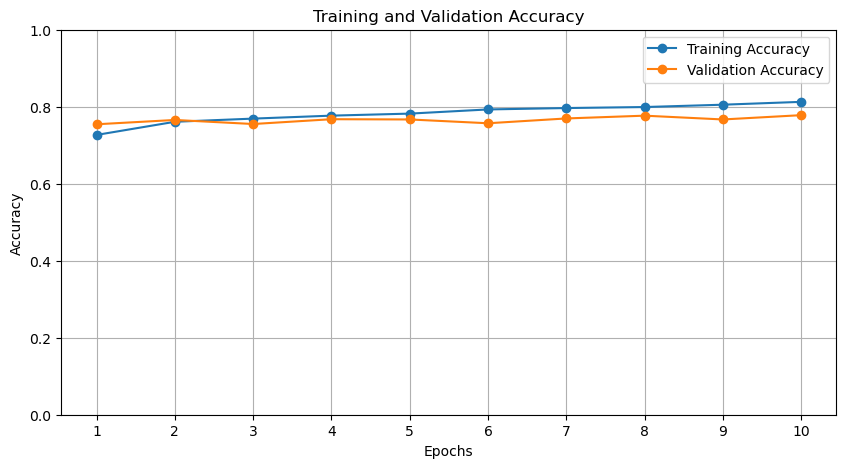

In [ ]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(train_accuracy) + 1)
# Plotting er c
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accuracy, label='Training Accuracy', marker='o')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(epochs)
plt.ylim([0, 1])
plt.legend()
plt.grid()
plt.show()


**Plotting graph of loss of train and validation**

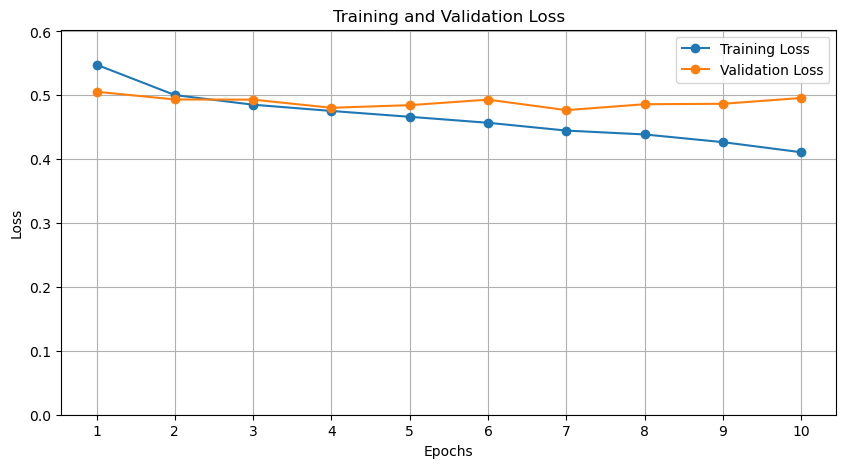

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)
# Plotting er code
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.ylim([0, max(max(train_loss), max(val_loss)) * 1.1])  # Adjust y-axis based on loss values
plt.legend()
plt.grid()
plt.show()

**Printing the accuracy and F1 score of train and valid data:**

In [ ]:
f1_2 = calculateF1Score(testing_padded, y_test, model2)
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy2 = history.history['val_accuracy'][-1]
print(f"Training Accuracy: {final_train_accuracy:.4f}")
print(f"Validation Accuracy: {final_val_accuracy2:.4f}")
print(f'F1 Score: {f1_2:.4f}')

48/48 [==============================] - 2s 38ms/step
Training Accuracy: 0.8126
Validation Accuracy: 0.7781
F1 Score: 0.7402


**Using GRU**

In [ ]:
# Define parameter , egula hyperparameters
vocab_size = 19416
embedding_dim = 50
drop_value = 0.2
n_dense = 24
learning_rate = 0.001

In [ ]:
model3 = Sequential()
model3.add(Embedding(vocab_size, embedding_dim,
                           weights=[embedding_matrix],
                           input_length=max_len,
                           trainable=False))
model3.add(SpatialDropout1D(0.2))
model3.add(GRU(128, return_sequences = False))
model3.add(Dropout(0.2))
model3.add(Dense(1, activation = 'relu'))
model3.build(input_shape =( None, max_len))

**Compile the model**

In [ ]:
model3.compile(loss = 'binary_crossentropy',
               optimizer = 'adam',
               metrics=['accuracy'])

In [ ]:
model3.summary()

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_10 (Embedding)    (None, 163, 50)           970800    
                                                                 
 spatial_dropout1d_5 (Spatia  (None, 163, 50)          0         
 lDropout1D)                                                     
                                                                 
 gru_2 (GRU)                 (None, 128)               69120     
                                                                 
 dropout_8 (Dropout)         (None, 128)               0         
                                                                 
 dense_8 (Dense)             (None, 1)                 129       
                                                                 
Total params: 1,040,049
Trainable params: 69,249
Non-trainable params: 970,800
________________________________________

**Train model**

In [ ]:
num_epochs = 30  # Increase epochs if needed
early_stop = EarlyStopping(monitor='val_loss', patience=3)  # Increase patience if needed
history = model3.fit(training_padded,
                     y_train,
                     epochs=num_epochs,
                     validation_data=(testing_padded, y_test),
                     callbacks=[early_stop],
                     verbose=2)

Epoch 1/30
191/191 - 13s - loss: 6.5778 - accuracy: 0.5736 - val_loss: 6.8263 - val_accuracy: 0.5575 - 13s/epoch - 68ms/step
Epoch 2/30
191/191 - 11s - loss: 6.5778 - accuracy: 0.5736 - val_loss: 6.8263 - val_accuracy: 0.5575 - 11s/epoch - 56ms/step
Epoch 3/30
191/191 - 11s - loss: 6.5778 - accuracy: 0.5736 - val_loss: 6.8263 - val_accuracy: 0.5575 - 11s/epoch - 55ms/step
Epoch 4/30
191/191 - 11s - loss: 6.5778 - accuracy: 0.5736 - val_loss: 6.8263 - val_accuracy: 0.5575 - 11s/epoch - 56ms/step


**Plotting graph of accuracy of train and validation**

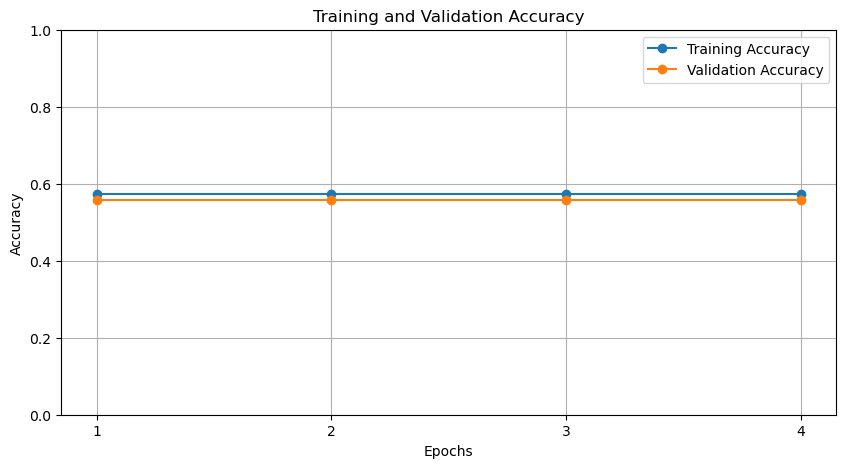

In [ ]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(train_accuracy) + 1)
# Plotting er code
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accuracy, label='Training Accuracy', marker='o')
plt.plot(epochs, val_accuracy, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.xticks(epochs)
plt.ylim([0, 1])
plt.legend()
plt.grid()
plt.show()


**Plotting graph of loss of train and validation**

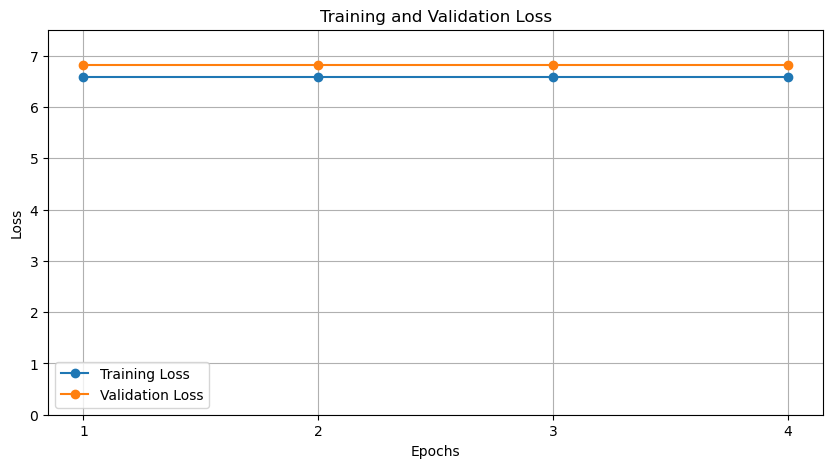

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)
# Plotting er code
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.ylim([0, max(max(train_loss), max(val_loss)) * 1.1])  # Adjust y-axis based on loss values
plt.legend()
plt.grid()
plt.show()

**Printing the accuracy and F1 of train and valid data:**

In [ ]:
f1_3 = calculateF1Score(testing_padded, y_test, model1)
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy3 = history.history['val_accuracy'][-1]
print(f"Training Accuracy: {final_train_accuracy:.4f}")
print(f"Validation Accuracy: {final_val_accuracy3:.4f}")
print(f'F1 Score: {f1_3:.4f}')

48/48 [==============================] - 1s 21ms/step
Training Accuracy: 0.5736
Validation Accuracy: 0.5575
F1 Score: 0.6136


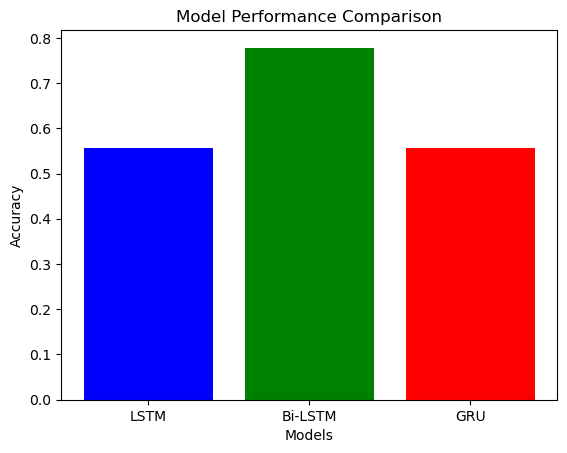

In [ ]:
models = ['LSTM', 'Bi-LSTM', 'GRU']
values = [final_val_accuracy1, final_val_accuracy2, final_val_accuracy3]
plt.bar(models, values, color=['blue', 'green', 'red'])
plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()

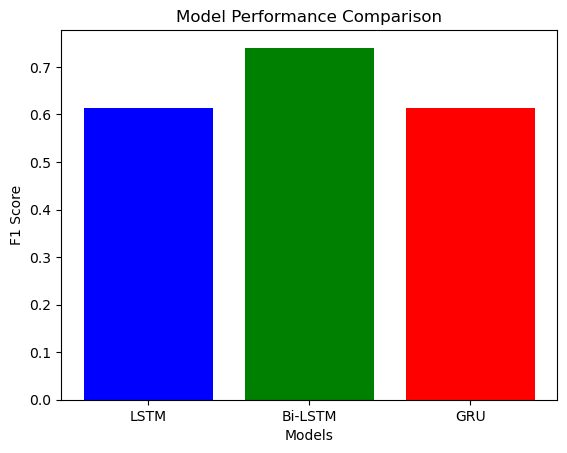

In [ ]:
models = ['LSTM', 'Bi-LSTM', 'GRU']
values = [f1_1, f1_2, f1_3]
plt.bar(models, values, color=['blue', 'green', 'red'])
plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('F1 Score')
plt.show()